
Label Encoding Mapping for Education:
2n Cycle --> 0
Basic --> 1
Graduation --> 2
Master --> 3
PhD --> 4

Encoded Dataset (First 5 Rows):
     ID  Year_Birth  Education   Income  Kidhome  Teenhome  \
0  5524        1957          2  58138.0        0         0   
1  2174        1954          2  46344.0        1         1   
2  4141        1965          2  71613.0        0         0   
3  6182        1984          2  26646.0        1         0   
4  5324        1981          4  58293.0        1         0   

           Dt_Customer  Recency  MntWines  MntFruits  ...  Z_Revenue  \
0  2012-04-09 00:00:00       58       635         88  ...         11   
1  2014-08-03 00:00:00       38        11          1  ...         11   
2           21-08-2013       26       426         49  ...         11   
3  2014-10-02 00:00:00       26        11          4  ...         11   
4           19-01-2014       94       173         43  ...         11   

   Response  Marital_Status_Absurd  Marital_Status_Alon

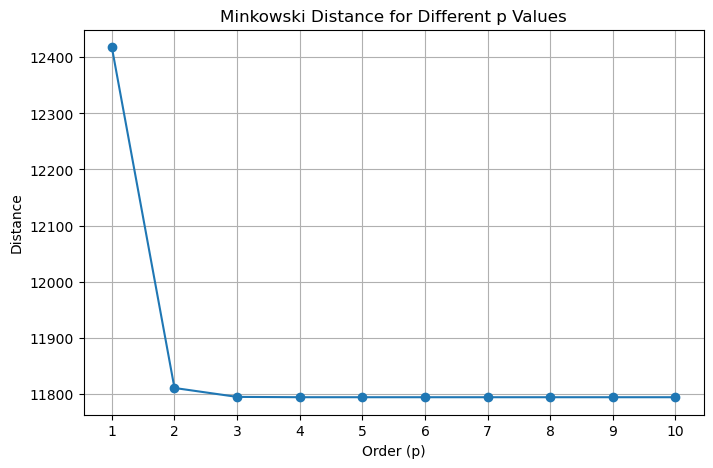

p	Custom		SciPy
-----------------------------------
1	12418.0000		12418.0000
2	11810.4958		11810.4958
3	11794.5822		11794.5822
4	11794.0231		11794.0231
5	11794.0010		11794.0010
6	11794.0000		11794.0000
7	11794.0000		11794.0000
8	11794.0000		11794.0000
9	11794.0000		11794.0000
10	11794.0000		11794.0000
Dot Product
Custom Function : 2694354457.0
NumPy Function  : 2694354457.0

Euclidean Norm of A
Custom Function : 58141.467723132
NumPy Function  : 58141.467723132

Euclidean Norm of B
Custom Function : 46344.00130545484
NumPy Function  : 46344.00130545484


In [9]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# Load Dataset
# -------------------------------
filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="marketing_campaign")  

# -------------------------------
# Label Encoding Function
# -------------------------------
def label_encode(df, column):
    """
    Performs Label Encoding on a categorical column.
    """
    le = LabelEncoder()

    df[column] = le.fit_transform(df[column].astype(str))

    print(f"\nLabel Encoding Mapping for {column}:")
    for original, encoded in zip(le.classes_, le.transform(le.classes_)):
        print(f"{original} --> {encoded}")

    return df


# -------------------------------
# One-Hot Encoding Function
# -------------------------------
def one_hot_encode(df, column):
    """
    Performs One-Hot Encoding on a categorical column.
    """
    df = pd.get_dummies(df,
                        columns=[column],
                        prefix=column,
                        dtype=int)

    return df


# -------------------------------
# Encode Categorical Columns
# -------------------------------

# Education -> Ordinal
df = label_encode(df, "Education")

# Marital_Status -> Nominal
df = one_hot_encode(df, "Marital_Status")


# -------------------------------
# Display Results
# -------------------------------

print("\nEncoded Dataset (First 5 Rows):")
print(df.head())

print("\nColumns after Encoding:")
print(df.columns.tolist())

print("\nShape of Dataset:")
print(df.shape)#29+7 = 36 columns

#A4
def minkowski_distance(x, y, p):
    """
    Computes the Minkowski distance between two vectors.

    Parameters:
        x : list or tuple
        y : list or tuple
        p : order of the distance
            p = 1 -> Manhattan
            p = 2 -> Euclidean

    Returns:
        Distance value
    """

    if len(x) != len(y):
        raise ValueError("Vectors must have the same length.")

    distance = 0

    for i in range(len(x)):
        distance += abs(x[i] - y[i]) ** p

    return distance ** (1 / p)
x = [2, 4, 6]
y = [5, 8, 10]

print("Manhattan Distance :", minkowski_distance(x, y, 1))
print("Euclidean Distance :", minkowski_distance(x, y, 2))
print("Minkowski (p=3)    :", minkowski_distance(x, y, 3))

#A5

# Select two numerical features
features = ["Income", "MntWines"]

# Remove missing values
data = df[features].dropna()

# Take first two samples
x = data.iloc[0].values
y = data.iloc[1].values

# Minkowski Distance Function
def minkowski_distance(x, y, p):
    distance = 0
    for i in range(len(x)):
        distance += abs(x[i] - y[i]) ** p
    return distance ** (1 / p)

# Calculate distances for p = 1 to 10
p_values = list(range(1, 11))
distances = []

for p in p_values:
    distances.append(minkowski_distance(x, y, p))

# Print distances
for p, d in zip(p_values, distances):
    print(f"p = {p}, Distance = {d:.4f}")

# Plot
plt.figure(figsize=(8,5))
plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance for Different p Values")
plt.xlabel("Order (p)")
plt.ylabel("Distance")
plt.xticks(p_values)
plt.grid(True)
plt.show()

#A6
from scipy.spatial.distance import minkowski

# Select two numerical features
data = df[["Income", "MntWines"]].dropna()

# Take first two samples
x = data.iloc[0].values
y = data.iloc[1].values

# User-defined Minkowski Distance Function
def minkowski_distance(x, y, p):
    distance = 0
    for i in range(len(x)):
        distance += abs(x[i] - y[i]) ** p
    return distance ** (1/p)

print("p\tCustom\t\tSciPy")
print("-"*35)

for p in range(1, 11):
    custom = minkowski_distance(x, y, p)
    scipy_dist = minkowski(x, y, p)
    print(f"{p}\t{custom:.4f}\t\t{scipy_dist:.4f}")

#A7
# Select two numerical features
data = df[["Income", "MntWines"]].dropna()

# Take first two vectors
A = data.iloc[0].values
B = data.iloc[1].values

# User-defined Dot Product
def dot_product(A, B):
    dot = 0
    for i in range(len(A)):
        dot += A[i] * B[i]
    return dot

# User-defined Euclidean Norm
def euclidean_norm(vector):
    sum_sq = 0
    for value in vector:
        sum_sq += value ** 2
    return sum_sq ** 0.5

# User-defined results
my_dot = dot_product(A, B)
my_norm_A = euclidean_norm(A)
my_norm_B = euclidean_norm(B)

# NumPy results
np_dot = np.dot(A, B)
np_norm_A = np.linalg.norm(A)
np_norm_B = np.linalg.norm(B)

# Display results
print("Dot Product")
print("Custom Function :", my_dot)
print("NumPy Function  :", np_dot)

print("\nEuclidean Norm of A")
print("Custom Function :", my_norm_A)
print("NumPy Function  :", np_norm_A)

print("\nEuclidean Norm of B")
print("Custom Function :", my_norm_B)
print("NumPy Function  :", np_norm_B)

In [13]:
#A8
import pandas as pd
import numpy as np
filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="marketing_campaign")  

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Convert to NumPy array
feat_vecs = numeric_df.values

# Mean vector (column-wise)
mean_vector = np.mean(feat_vecs, axis=0)

# Variance vector (column-wise)
variance_vector = np.var(feat_vecs, axis=0)

# Standard deviation vector (column-wise)
std_vector = np.std(feat_vecs, axis=0)

# Display as a matrix
result = pd.DataFrame(
    [mean_vector, variance_vector, std_vector],
    index=["Mean", "Variance", "Standard Deviation"],
    columns=numeric_df.columns
)

print(result)

                              ID   Year_Birth  Income   Kidhome  Teenhome  \
Mean                5.592160e+03  1968.805804     NaN  0.444196  0.506250   
Variance            1.053611e+07   143.553806     NaN  0.289743  0.296390   
Standard Deviation  3.245937e+03    11.981394     NaN  0.538278  0.544417   

                       Recency       MntWines    MntFruits  MntMeatProducts  \
Mean                 49.109375     303.935714    26.302232       166.950000   
Variance            838.449198  113247.225332  1581.219816     50924.685000   
Standard Deviation   28.955987     336.522251    39.764555       225.664984   

                    MntFishProducts  ...  NumWebVisitsMonth  AcceptedCmp3  \
Mean                      37.525446  ...           5.316518      0.072768   
Variance                2982.993102  ...           5.885977      0.067473   
Standard Deviation        54.616784  ...           2.426103      0.259755   

                    AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  Acc

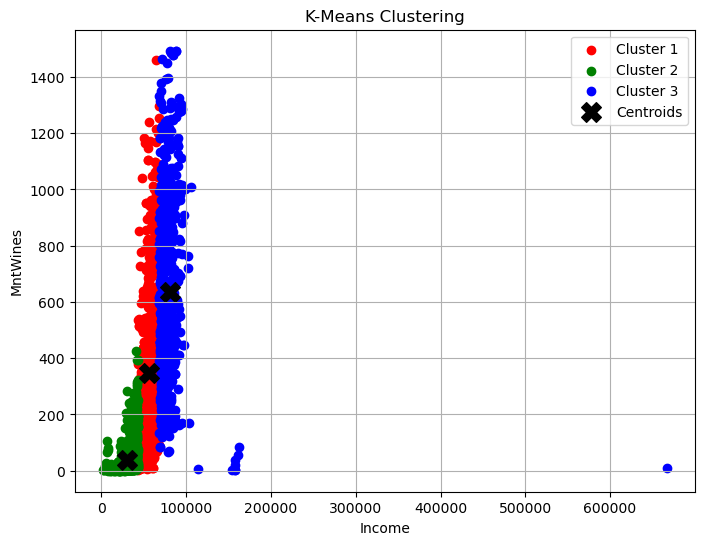

In [17]:
#A10
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# -------------------------------
# Load Dataset
# -------------------------------
filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="marketing_campaign")  
# Use two numerical features
data = df[["Income", "MntWines"]].dropna().values

# Number of clusters
K = 3

# Initialize centroids (first K points)
centroids = data[:K].copy()

# Euclidean Distance Function
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

# K-Means Algorithm
while True:

    clusters = [[] for _ in range(K)]

    # Assign each point to nearest centroid
    for point in data:
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        cluster = np.argmin(distances)
        clusters[cluster].append(point)

    # Compute new centroids
    new_centroids = []

    for cluster in clusters:
        new_centroids.append(np.mean(cluster, axis=0))

    new_centroids = np.array(new_centroids)

    # Stop if centroids do not change
    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

# Plot clusters
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for i in range(K):
    cluster = np.array(clusters[i])
    plt.scatter(cluster[:,0], cluster[:,1], color=colors[i], label=f'Cluster {i+1}')

plt.scatter(centroids[:,0], centroids[:,1],
            color='black', marker='X', s=200, label='Centroids')

plt.xlabel("Income")
plt.ylabel("MntWines")
plt.title("K-Means Clustering")
plt.legend()
plt.grid(True)
plt.show()

Histogram Counts: [1654  554    7    0    0    0    0    0    0    1]
Bin Edges: [  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]
Mean = 52247.25135379061
Variance = 633397830.1872728


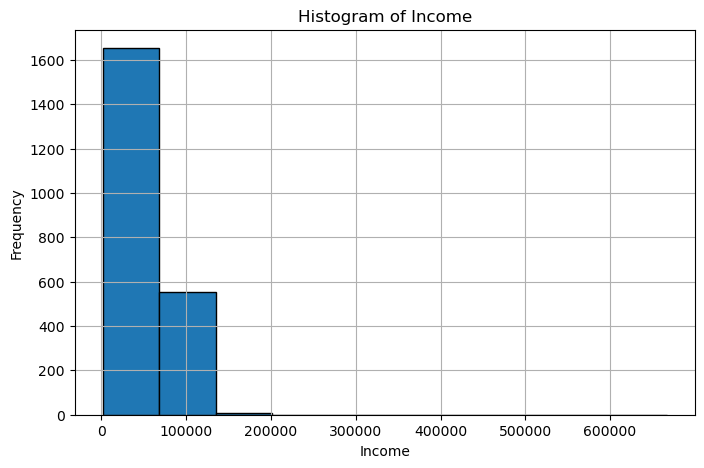

In [16]:
#A11
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
# -------------------------------
filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="marketing_campaign")  

# Select a numerical feature
feature = df["Income"].dropna()

# Calculate histogram data
hist, bins = np.histogram(feature, bins=10)

print("Histogram Counts:", hist)
print("Bin Edges:", bins)

# Calculate Mean and Variance
mean = np.mean(feature)
variance = np.var(feature)

print("Mean =", mean)
print("Variance =", variance)

# Plot Histogram
plt.figure(figsize=(8,5))
plt.hist(feature, bins=10, edgecolor='black')
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [19]:
#A11
import pandas as pd
import numpy as np

# -------------------------------
# Load Dataset
# -------------------------------
filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="marketing_campaign")  

# Select two numerical features
data = df[["Income", "MntWines"]].dropna().values

# -------------------------
# Euclidean Distance Function (Reused)
# -------------------------
def euclidean_distance(x, y):
    distance = 0
    for i in range(len(x)):
        distance += (x[i] - y[i]) ** 2
    return distance ** 0.5

# -------------------------
# Mean Function (Reused)
# -------------------------
def mean(values):
    total = 0
    for value in values:
        total += value
    return total / len(values)

# -------------------------
# Compute Centroid using Mean Function
# -------------------------
def compute_centroid(cluster):
    centroid = []

    for j in range(len(cluster[0])):      # For each feature
        column = []
        for point in cluster:
            column.append(point[j])

        centroid.append(mean(column))

    return centroid

# -------------------------
# K-Means Algorithm
# -------------------------
def kmeans(data, K):

    # Step 1: Select K initial centroids
    centroids = data[:K].tolist()

    while True:

        # Step 2: Create K empty clusters
        clusters = [[] for _ in range(K)]

        # Step 3: Assign points to nearest centroid
        for point in data:

            distances = []

            for centroid in centroids:
                distances.append(euclidean_distance(point, centroid))

            nearest = distances.index(min(distances))
            clusters[nearest].append(point.tolist())

        # Step 4: Recompute centroids
        new_centroids = []

        for cluster in clusters:
            new_centroids.append(compute_centroid(cluster))

        # Step 5: Stop if centroids do not change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids

# Number of clusters
K = 3

clusters, centroids = kmeans(data, K)

# Display Results
for i in range(K):
    print(f"\nCluster {i+1}:")
    print(np.array(clusters[i]))

print("\nFinal Centroids:")
print(np.array(centroids))


Cluster 1:
[[5.8138e+04 6.3500e+02]
 [4.6344e+04 1.1000e+01]
 [5.8293e+04 1.7300e+02]
 ...
 [6.4014e+04 4.0600e+02]
 [5.6981e+04 9.0800e+02]
 [5.2869e+04 8.4000e+01]]

Cluster 2:
[[2.6646e+04 1.1000e+01]
 [3.3454e+04 7.6000e+01]
 [3.0351e+04 1.4000e+01]
 ...
 [1.1012e+04 2.4000e+01]
 [2.6816e+04 5.0000e+00]
 [3.4421e+04 3.0000e+00]]

Cluster 3:
[[7.16130e+04 4.26000e+02]
 [8.28000e+04 1.00600e+03]
 [7.69950e+04 1.01200e+03]
 ...
 [7.57770e+04 7.12000e+02]
 [6.66666e+05 9.00000e+00]
 [6.92450e+04 4.28000e+02]]

Final Centroids:
[[5.56852568e+04 3.47049383e+02]
 [2.98794719e+04 3.90107527e+01]
 [8.02561213e+04 6.36768014e+02]]
